In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display
from datetime import datetime
import os
import ast

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

# print(f"Pandas версия: {pd.__version__}")
# print(f"NumPy версия: {np.__version__}")
# print(f"Matplotlib версия: {plt.matplotlib.__version__}")
# print(f"Seaborn версия: {sns.__version__}")

In [2]:
url = "C:\\Users\\HOME\\Documents\\CV2026\\applications_2026\\FEB 2026\\Palta\\simple_interview_events_v2.csv"

try:
    events = pd.read_csv(url)
    print(f"✓ File successfully loaded: {len(events)} rows, {len(events.columns)} columns")
except Exception as e:
    print(f"Error: {e}")

✓ File successfully loaded: 3099802 rows, 4 columns


In [3]:
events.head(5)

,user_id,event_type,event_time,event_params
0,0,funnel_start,2024-01-01T00:00:08,"{""funnel_type"": ""activity""}"
1,1,funnel_start,2024-01-01T00:00:32,"{""funnel_type"": ""fasting""}"
2,2,funnel_start,2024-01-01T00:00:35,"{""funnel_type"": ""fasting""}"
3,1,profile_start,2024-01-01T00:00:39,{}
4,3,funnel_start,2024-01-01T00:00:55,"{""funnel_type"": ""activity""}"


## 0. Data Sanity Check
#### 0.1 Dataset structure and data types

In [4]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3099802 entries, 0 to 3099801
Data columns (total 4 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   user_id       int64 
 1   event_type    object
 2   event_time    object
 3   event_params  object
dtypes: int64(1), object(3)
memory usage: 94.6+ MB


#### 0.2 Basic data logic check

In [5]:
print("Number of unique users:", events["user_id"].nunique())
print("Number of unique event types:", events["event_type"].nunique())
print("Event type distribution:")
print(events["event_type"].value_counts())

Number of unique users: 1000000
Number of unique event types: 6
Event type distribution:
funnel_start           1000000
profile_start           736792
email_submit            590258
paywall_show            539473
experiment_exposure     188985
payment_done             44294
Name: event_type, dtype: int64


In [6]:
def quick_overview(df, name="dataset"):
    """
    Provides a concise structural overview of a dataframe.
    """

    print(f"\n{'=' * 60}")
    print(f"DATASET OVERVIEW: {name}")
    print(f"{'=' * 60}")

    # Shape
    rows, cols = df.shape
    print(f"Shape: {rows:,} rows × {cols} columns")

    # Memory usage
    memory_mb = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory usage: {memory_mb:.2f} MB")

    # Data types
    print("\nData types:")
    print(df.dtypes.value_counts())

    # Missing values
    missing = df.isna().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print("\nColumns with missing values:")
        print(missing.sort_values(ascending=False))
    else:
        print("\nNo missing values detected.")

    # Unique counts for key identifiers (if exist)
    if "user_id" in df.columns:
        print(f"\nUnique users: {df['user_id'].nunique():,}")

    if "event_type" in df.columns:
        print(f"Unique event types: {df['event_type'].nunique()}")

    print("\nSample rows:")
    display(df.head(3))

In [7]:
quick_overview(events, "events")


DATASET OVERVIEW: events
Shape: 3,099,802 rows × 4 columns
Memory usage: 661.62 MB

Data types:
object    3
int64     1
dtype: int64

No missing values detected.

Unique users: 1,000,000
Unique event types: 6

Sample rows:


,user_id,event_type,event_time,event_params
0,0,funnel_start,2024-01-01T00:00:08,"{""funnel_type"": ""activity""}"
1,1,funnel_start,2024-01-01T00:00:32,"{""funnel_type"": ""fasting""}"
2,2,funnel_start,2024-01-01T00:00:35,"{""funnel_type"": ""fasting""}"


In [8]:
def check_missing_values(df, name="dataset", visualize=True):

    total_rows = len(df)

    missing_count = df.isna().sum()
    missing_pct = (missing_count / total_rows) * 100

    summary = (
        pd.DataFrame({
            "column": missing_count.index,
            "missing_count": missing_count.values,
            "missing_pct": missing_pct.values
        })
        .query("missing_count > 0")
        .sort_values("missing_count", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n{'=' * 60}")
    print(f"MISSING VALUE ANALYSIS: {name}")
    print(f"{'=' * 60}")

    if summary.empty:
        print("✓ No missing values detected.")
        return summary

    print(f"Columns with missing values: {len(summary)}")
    display(summary)

    if visualize:
        plt.figure(figsize=(10, 5))
        plt.barh(summary["column"], summary["missing_pct"])
        plt.xlabel("Missing values (%)")
        plt.title(f"Missing value distribution — {name}")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

    return summary

In [9]:
check_missing_values(events)


MISSING VALUE ANALYSIS: dataset
✓ No missing values detected.


,column,missing_count,missing_pct


# 1. Web Funnel Events
## Task
Given a dataset of events from a web funnel calculate the percentage of users from the initial number (at `funnel_start`) who proceed to each stage of the funnel and the percentage of users lost at each stage. There are following stages with corresponding event types:

- `funnel_start`: The start of the funnel (user lands on the landing page).
- `profile_start`: The user starts filling out the profile.
- `email_submit`: The user enters their email address.
- `paywall_show`: The paywall is displayed.
- `payment_done`: The user completes a purchase.

Using the `experiment_exposure` event (user was included in the experiment), select the 3 most promising experiments and justify your choice.

### Approach
Using the event-level dataset, we will:
1) Calculate the share of users (from the initial `funnel_start` cohort) who reach each funnel stage.
2) Calculate the percentage of users lost at each stage (stage-to-stage drop-off).
3) Using `experiment_exposure`, identify the 3 most promising experiments and justify the selection.

#### 1.1 Funnel conversion + drop-off
Count unique users per funnel stage, compute conversion from start and drop-off between consecutive steps.

In [10]:
stages = ["funnel_start", "profile_start", "email_submit", "paywall_show", "payment_done"]
# stages

In [11]:
stage_users = (
    events[events["event_type"].isin(stages)]
    .groupby("event_type")["user_id"]
    .nunique()
    .reindex(stages)
)

In [12]:
baseline = stage_users.loc["funnel_start"]
baseline

1000000

In [13]:
funnel_df = pd.DataFrame({
    "stage": stage_users.index,
    "users": stage_users.values
})

In [14]:
funnel_df["conversion_from_start_pct"] = (funnel_df["users"] / baseline * 100).round(2)
funnel_df["drop_off_from_prev_pct"] = (1 - funnel_df["users"] / funnel_df["users"].shift(1)).mul(100).round(2)
funnel_df.loc[0, "drop_off_from_prev_pct"] = 0.0

In [15]:
funnel_df["lost_users_from_prev"] = (funnel_df["users"].shift(1) - funnel_df["users"]).fillna(0).astype(int)

In [16]:
funnel_df

,stage,users,conversion_from_start_pct,drop_off_from_prev_pct,lost_users_from_prev
0,funnel_start,1000000,100.00,0.00,0
1,profile_start,736792,73.68,26.32,263208
2,email_submit,590258,59.03,19.89,146534
3,paywall_show,539473,53.95,8.60,50785
4,payment_done,44294,4.43,91.79,495179


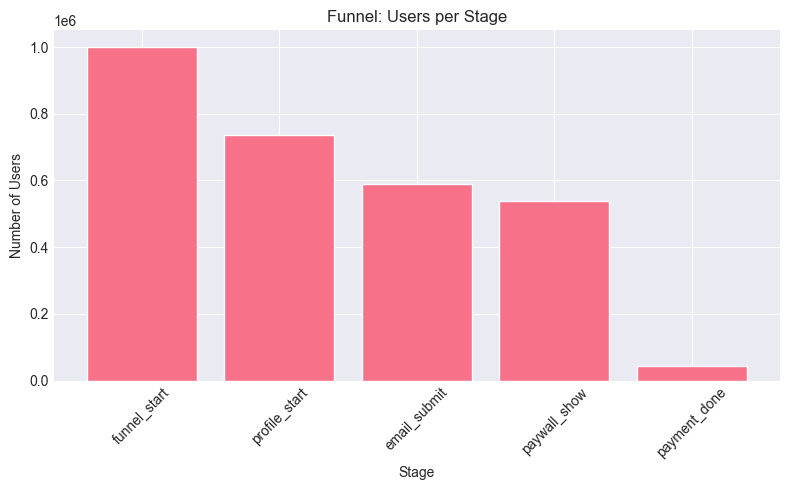

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(funnel_df["stage"], funnel_df["users"])
plt.title("Funnel: Users per Stage")
plt.xlabel("Stage")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

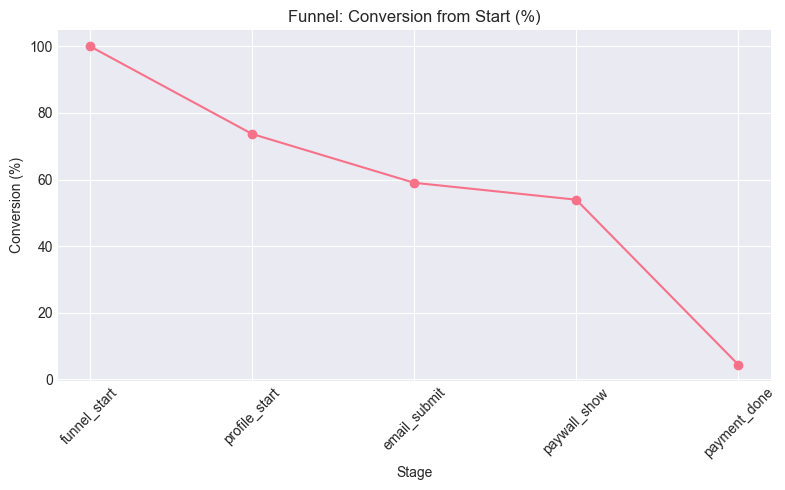

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(funnel_df["stage"], funnel_df["conversion_from_start_pct"], marker="o")
plt.title("Funnel: Conversion from Start (%)")
plt.xlabel("Stage")
plt.ylabel("Conversion (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

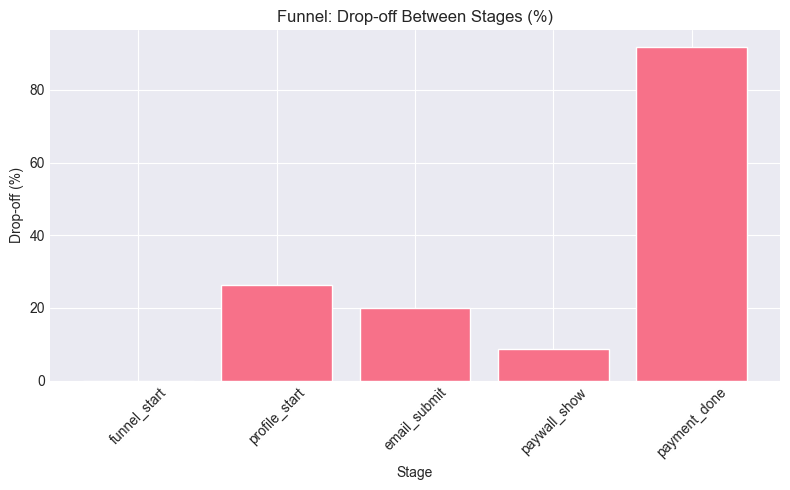

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(funnel_df["stage"], funnel_df["drop_off_from_prev_pct"])
plt.title("Funnel: Drop-off Between Stages (%)")
plt.xlabel("Stage")
plt.ylabel("Drop-off (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.2 Top-3 experiments

In [22]:
exposures = events[events["event_type"] == "experiment_exposure"][["user_id", "event_params"]].copy()

In [23]:
exposures["experiment_name"] = exposures["event_params"].apply(
    lambda x: ast.literal_eval(x).get("experiment_name") if isinstance(x, str) else None
)

In [24]:
exposures = exposures.dropna(subset=["experiment_name"])

In [25]:
print("Unique experiments:", exposures["experiment_name"].nunique())

Unique experiments: 10


In [26]:
# users who completed payment
buyers = set(events.loc[events["event_type"] == "payment_done", "user_id"].unique())
buyers

{524291,
 917509,
 7,
 262158,
 786451,
 524308,
 131095,
 524312,
 655383,
 917534,
 131105,
 655393,
 524324,
 786469,
 38,
 524333,
 917550,
 49,
 262196,
 393272,
 917562,
 524350,
 262207,
 393283,
 524355,
 393289,
 917580,
 786511,
 524374,
 393311,
 393313,
 786531,
 393318,
 131175,
 786536,
 917610,
 112,
 786547,
 524405,
 131193,
 122,
 786555,
 262268,
 131206,
 524422,
 524425,
 524436,
 131230,
 393375,
 917662,
 161,
 262306,
 131235,
 131240,
 655536,
 180,
 262325,
 393398,
 786620,
 524480,
 786625,
 786626,
 917697,
 196,
 524485,
 786628,
 917702,
 262347,
 786636,
 131278,
 393422,
 524494,
 655569,
 786640,
 917711,
 917714,
 917719,
 524505,
 131290,
 393436,
 131293,
 131294,
 131303,
 234,
 262378,
 524534,
 393472,
 655616,
 131331,
 786693,
 655625,
 917772,
 131341,
 262413,
 786703,
 393488,
 917777,
 131355,
 917789,
 286,
 393504,
 289,
 786724,
 393521,
 393522,
 131382,
 393528,
 786745,
 131387,
 131390,
 786760,
 335,
 337,
 393553,
 786779,
 786782,

In [27]:
# unique exposed users per experiment
exp_df = (
    exposures.groupby("experiment_name")["user_id"]
    .nunique()
    .reset_index(name="exposed_users")
)

exp_df.head(4)

,experiment_name,exposed_users
0,exp_0,28221
1,exp_1,12566
2,exp_2,9476
3,exp_3,70397


In [28]:
# Buyers among exposed
buyers_df = (
    exposures[exposures["user_id"].isin(buyers)]
    .groupby("experiment_name")["user_id"]
    .nunique()
    .reset_index(name="buyers_among_exposed")
)

buyers_df

,experiment_name,buyers_among_exposed
0,exp_0,2592
1,exp_1,961
2,exp_2,652
3,exp_3,3076
4,exp_4,2165
5,exp_5,430
6,exp_6,579
7,exp_7,917
8,exp_8,283
9,exp_9,287


In [29]:
exp_df = exp_df.merge(buyers_df, on="experiment_name", how="left")

In [30]:
exp_df["buyers_among_exposed"] = exp_df["buyers_among_exposed"].fillna(0)

In [31]:
# conversion rate
exp_df["purchase_cvr_pct"] = (
    exp_df["buyers_among_exposed"] / exp_df["exposed_users"] * 100
).round(2)

In [32]:
exp_df.sort_values("purchase_cvr_pct", ascending=False)

,experiment_name,exposed_users,buyers_among_exposed,purchase_cvr_pct
6,exp_6,579,579,100.00
0,exp_0,28221,2592,9.18
1,exp_1,12566,961,7.65
2,exp_2,9476,652,6.88
7,exp_7,14232,917,6.44
5,exp_5,6742,430,6.38
4,exp_4,34781,2165,6.22
8,exp_8,5884,283,4.81
9,exp_9,6107,287,4.70
3,exp_3,70397,3076,4.37


In [33]:
min_users1000 = 1000  # avoid very small experiments

In [34]:
top3_min1000 = (
    exp_df[exp_df["exposed_users"] >= min_users1000]
    .sort_values(["purchase_cvr_pct", "exposed_users"], ascending=False)
    .head(3)
)

top3_min1000

,experiment_name,exposed_users,buyers_among_exposed,purchase_cvr_pct
0,exp_0,28221,2592,9.18
1,exp_1,12566,961,7.65
2,exp_2,9476,652,6.88


In [35]:
thresholds = [500, 1000, 2000]

In [36]:
top3_by_threshold = {}

for t in thresholds:
    top3_by_threshold[t] = (
        exp_df[exp_df["exposed_users"] >= t]
        .sort_values(["purchase_cvr_pct", "exposed_users"], ascending=False)
        .head(3)
        .reset_index(drop=True)
    )

for t, df_top in top3_by_threshold.items():
    print(f"\nTop-3 experiments (min_users = {t})")
    display(df_top)


Top-3 experiments (min_users = 500)


,experiment_name,exposed_users,buyers_among_exposed,purchase_cvr_pct
0,exp_6,579,579,100.00
1,exp_0,28221,2592,9.18
2,exp_1,12566,961,7.65



Top-3 experiments (min_users = 1000)


,experiment_name,exposed_users,buyers_among_exposed,purchase_cvr_pct
0,exp_0,28221,2592,9.18
1,exp_1,12566,961,7.65
2,exp_2,9476,652,6.88



Top-3 experiments (min_users = 2000)


,experiment_name,exposed_users,buyers_among_exposed,purchase_cvr_pct
0,exp_0,28221,2592,9.18
1,exp_1,12566,961,7.65
2,exp_2,9476,652,6.88


### CONCLUSION: Sensitivity to Minimum Exposure Threshold

- When `min_users = 500`, experiment **exp_6** appears with a 100% conversion rate.
- However, exp_6 has only 579 exposed users and 579 buyers, which indicates a data anomaly or extremely small-scale behavior.
- Such results are not reliable for decision-making.

When increasing the threshold to:
- `min_users = 1000`
- `min_users = 2000`

The Top-3 experiments remain stable:
- **exp_0**
- **exp_1**
- **exp_2**

This indicates robustness of the ranking.

### Most Promising Experiments
1. **exp_0** – 9.18% conversion (28,221 users)
   → Highest conversion and largest sample size.
   → Strong candidate for scaling.

2. **exp_1** – 7.65% conversion (12,566 users)
   → Solid performance with substantial exposure size.

3. **exp_2** – 6.88% conversion (9,476 users)
   → Lower than exp_0 and exp_1, but still significant with large sample size.

### Using a minimum exposure threshold of **1000+ users** is appropriate.

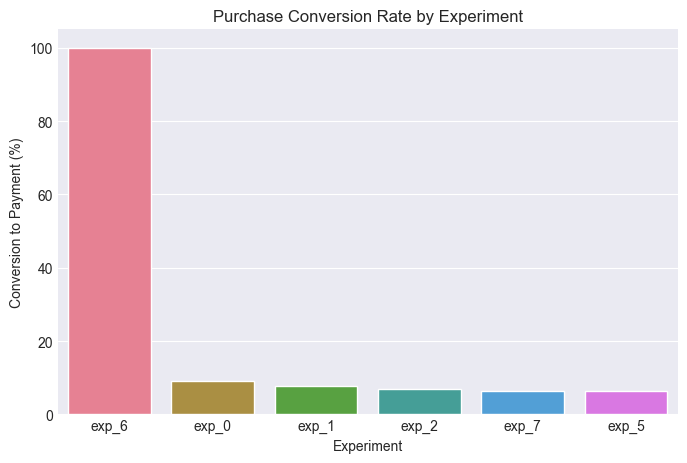

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=exp_df.sort_values("purchase_cvr_pct", ascending=False).head(6),
    x="experiment_name",
    y="purchase_cvr_pct"
)

plt.title("Purchase Conversion Rate by Experiment")
plt.xlabel("Experiment")
plt.ylabel("Conversion to Payment (%)")

plt.show()

#### Conclusions: **Purchase Conversion Rate by Experiment**

* Experiment `exp_6` demonstrates an extremely high conversion rate (~100%), which is significantly higher than all other experiments. However, this result should be interpreted with caution because the experiment has a very small exposure size (579 users), making it statistically unreliable.

* Among experiments with large exposure sizes, `exp_0` shows the strongest performance with a conversion rate of **9.18%**, followed by `exp_1` (7.65%) and `exp_2` (6.88%).


In [38]:
baseline_cvr = funnel_df.loc[
    funnel_df["stage"] == "payment_done",
    "conversion_from_start_pct"
].iloc[0]

baseline_cvr

4.43

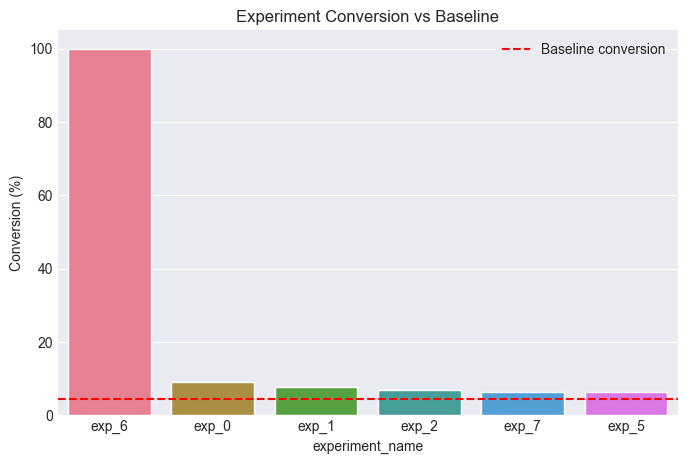

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=exp_df.sort_values("purchase_cvr_pct", ascending=False).head(6),
    x="experiment_name",
    y="purchase_cvr_pct"
)

plt.axhline(
    baseline_cvr,
    color="red",
    linestyle="--",
    label="Baseline conversion"
)

plt.title("Experiment Conversion vs Baseline")
plt.ylabel("Conversion (%)")
plt.legend()

plt.show()

#### Conclusions: **Experiment Conversion vs Baseline**

* This chart compares the conversion rate of each experiment with the overall funnel baseline conversion (**4.43%**).
* Several experiments outperform the baseline, indicating a potential improvement in monetization efficiency.
* In particular, experiments `exp_0`, `exp_1`, and `exp_2` show consistently higher conversion rates compared to the baseline while also maintaining large exposure sizes.

In [40]:
exp_df["uplift_vs_baseline_pct"] = (
    (exp_df["purchase_cvr_pct"] - baseline_cvr) / baseline_cvr * 100
).round(1)

exp_df.sort_values("uplift_vs_baseline_pct", ascending=False).head()

,experiment_name,exposed_users,buyers_among_exposed,purchase_cvr_pct,uplift_vs_baseline_pct
6,exp_6,579,579,100.00,2157.3
0,exp_0,28221,2592,9.18,107.2
1,exp_1,12566,961,7.65,72.7
2,exp_2,9476,652,6.88,55.3
7,exp_7,14232,917,6.44,45.4


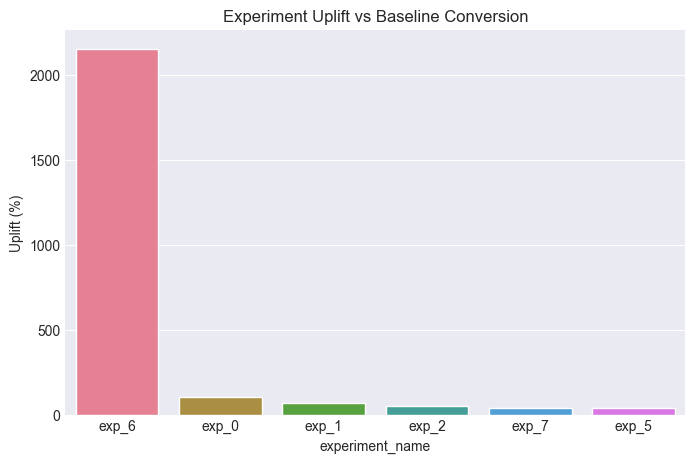

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=exp_df.sort_values("uplift_vs_baseline_pct", ascending=False).head(6),
    x="experiment_name",
    y="uplift_vs_baseline_pct"
)

plt.title("Experiment Uplift vs Baseline Conversion")
plt.ylabel("Uplift (%)")

plt.show()

#### Conclusions: **Experiment Uplift vs Baseline**

* Experiment `exp_6` displays an extremely large uplift due to its near-perfect conversion rate. However, because the sample size is very small, this result is likely driven by noise rather than a true product improvement.
* In contrast, experiments `exp_0`, `exp_1`, and `exp_2` show meaningful positive uplift while maintaining significantly larger user samples.

### Final Experiment Ranking

Based on conversion performance and exposure size, the most promising experiments are:

1. **exp_0** – highest reliable conversion uplift and the largest exposed user base.
2. **exp_1** – strong improvement over baseline with a substantial sample size.
3. **exp_2** – moderate uplift with good statistical reliability.

Although `exp_6` shows the highest conversion rate, its very small exposure size makes it unsuitable for product decisions without further validation.

## Final Experiment Ranking

| Experiment | Exposed Users | Conversion | Uplift vs Baseline |
|------------|--------------|------------|--------------------|
| exp_0 | 28,221 | 9.18% | strong |
| exp_1 | 12,566 | 7.65% | moderate |
| exp_2 | 9,476 | 6.88% | moderate |

Experiment `exp_0` is the most promising candidate for scaling due to both high conversion uplift and large exposure size.

##### The overall funnel conversion from `funnel_start` to `payment_done` is **4.43%**.

This means that out of all users who enter the funnel, only a small fraction completes the purchase. Such a drop is typical for subscription funnels, where multiple steps introduce friction before reaching the paywall and final payment.

This baseline conversion is useful as a reference point when evaluating experiment performance. Experiments that significantly outperform the **4.43% baseline** may represent meaningful improvements in monetization efficiency.

### Key Analytical Insight

Experiment evaluation should consider both _conversion performance_ and _sample size_.

Experiments with extremely high conversion but very small exposure may produce misleading results due to statistical noise.

Therefore, experiments `exp_0`, `exp_1`, and `exp_2` are considered the most promising candidates for further testing or rollout.

In [43]:
exp_filtered = exp_df[exp_df["exposed_users"] >= 1000]

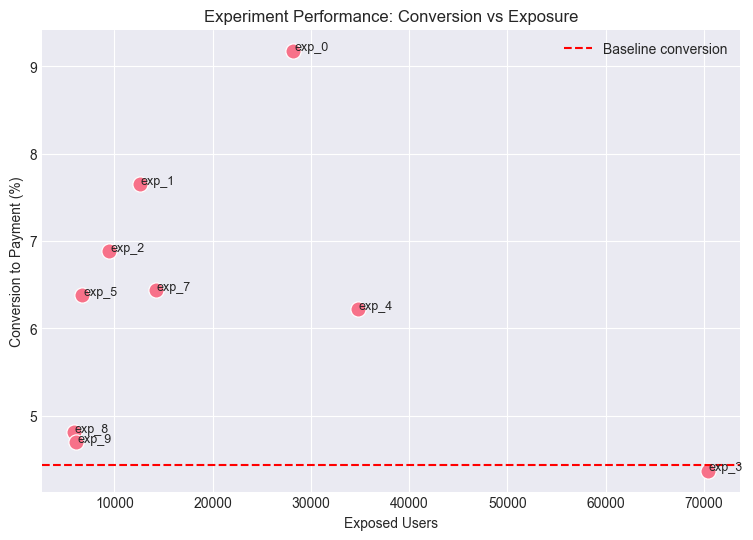

In [44]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=exp_filtered,
    x="exposed_users",
    y="purchase_cvr_pct",
    s=120
)

for i, row in exp_filtered.iterrows():
    plt.text(
        row["exposed_users"] + 100,
        row["purchase_cvr_pct"],
        row["experiment_name"],
        fontsize=9
    )

plt.axhline(baseline_cvr, linestyle="--", color="red", label="Baseline conversion")

plt.title("Experiment Performance: Conversion vs Exposure")
plt.xlabel("Exposed Users")
plt.ylabel("Conversion to Payment (%)")

plt.legend()
plt.show()

# 2. Task - Monetization & Subscription Analytics

On the `payment_done` event, users purchase a subscription-based product.

### 1) Data Limitations & Monetization Analysis

Answer the following:

- What potential problems or limitations do you see in this dataset for a comprehensive monetization analysis?
- Could adding additional data change your choice of the most promising experiments from Part 1?
- If yes, what kind of data and how exactly would it affect your decision-making?

### 2) Proxy Metrics for Revenue

Since direct revenue and pricing data are not available:

- Which proxy metrics would you use to estimate the impact of experiments on monetization?
- Which of these proxy metrics do you consider:
  - the most sensitive?
  - the most robust / stable?
  - potentially dangerous (i.e., may lead to incorrect or misleading conclusions)?

Please explain your reasoning.

### 2.1 Data Limitations & Monetization Analysis

#### Key Limitations of the Dataset

The current dataset contains only event-level behavioral data and lacks core monetization dimensions required for full subscription analysis.

Main limitations:

1. No revenue information
   - We do not know subscription price, discounts, or plan type.
   - Cannot calculate ARPU, ARPPU, or revenue uplift.

2. No subscription lifecycle data
   - No renewals, churn, cancellations, refunds.
   - We only observe initial purchase (`payment_done`).

3. No customer lifetime value (LTV) metrics
   - We cannot assess long-term monetization impact.
   - An experiment increasing short-term conversion may reduce long-term retention.

4. No acquisition cost (CAC) or marketing data
   - Cannot evaluate unit economics or profitability.

5. No segmentation (geo, device, payment method, etc.)
   - Monetization behavior may differ significantly across segments.

#### Could Additional Data Change Experiment Ranking?

Yes.

Currently, experiments are ranked by purchase conversion rate only.
However, adding monetization data could change the decision.

For example:

- If an experiment increases conversion but attracts lower-value subscribers,
  its LTV could be lower than competitors.
- If churn rate is higher for one experiment, short-term gains may disappear.

#### What Additional Data Would Improve Decision-Making?

1. Subscription price / revenue per user
   → Enables ARPU and revenue uplift calculation.

2. Renewal / churn events
   → Allows retention and LTV estimation.

3. Refund / cancellation data
   → Detects low-quality purchases.

4. Plan type (monthly vs yearly)
   → Impacts cashflow and long-term value.

5. Cohort retention curves
   → Compares quality of users acquired via each experiment.

With LTV data, the “most promising” experiment could change from the one with highest conversion to the one with highest lifetime value.

## 2.2 Proxy Metrics for Revenue Impact

Since direct revenue and pricing data are not available, we rely on proxy metrics that approximate monetization outcomes.

Given that the product is a subscription-based weight loss application, user engagement and retention are critical drivers of long-term revenue.

Therefore, both purchase behavior and engagement signals should be considered.

### Candidate Proxy Metrics

1. Conversion from `funnel_start` → `payment_done`
Measures the overall ability of the funnel to convert users into paying subscribers.

2. Conversion from `paywall_show` → `payment_done`
Directly measures the effectiveness of the paywall and pricing communication.

3. Number of `payment_done` events
Indicates the absolute number of acquired subscribers.

4. Early engagement metrics (if available in future datasets)
For a weight-loss application these could include:
- number of logged meals
- workout completion
- daily active usage
- streaks or habit formation metrics

These engagement metrics often correlate with subscription retention and lifetime value (LTV).

### Most Sensitive Proxy Metric

Conversion from `funnel_start` → `payment_done`

Why?
- Captures the full funnel impact.
- Quickly reacts to experiment changes.
- Sensitive to improvements at any funnel stage.

However, it can also be influenced by early-stage noise.

### Most Robust / Stable Proxy Metric

Conversion from `paywall_show` → `payment_done`
Why?

- Closest step to monetization.
- Reflects the user's final purchase decision.
- Less influenced by upstream behavioral variability.

For subscription products, this metric is often the most reliable indicator of monetization efficiency.

### Potentially Dangerous Proxy Metrics

Early engagement metrics such as:
- `profile_start`
- `email_submit`

Why?
- These may increase without improving actual purchases.
- Optimizing early engagement can create misleading conclusions if it does not translate into subscription purchases.

For example, an experiment might increase email submissions by 20% but produce no increase in `payment_done`.

# 3. Task - Funnel Types & User Differences

The dataset contains multiple funnel types (`funnel_type`).

- How do you expect users from different funnel types to differ?
- Should experiments be analyzed separately by `funnel_type`?
- Why or why not?

## 3.1 Funnel Types & User Differences

### How Users from Different Funnel Types May Differ

Different `funnel_type` values likely represent different acquisition flows, user intents, or product entry points.

Users may differ in:

1. Intent level
   Some funnels may attract highly motivated users (e.g., goal-oriented),
   while others may attract exploratory users.

2. Price sensitivity
   Funnel messaging may frame value differently, affecting willingness to pay.

3. Engagement depth
   Certain funnel types may encourage stronger early engagement,
   which could correlate with higher purchase probability.

4. Demographic or behavioral segments
   Different funnels may implicitly segment users by acquisition source or value proposition.

### Should Experiments Be Analyzed Separately by funnel_type?

## 3.2 Funnel Types & User Differences

The answer depends on behavioral differences and sample size.

**YES**, if:
- Conversion rates differ materially across funnel types.
- User intent and monetization patterns are clearly distinct.
- Interaction effect between experiment and funnel_type exists.

Separating analysis allows:
- More precise optimization.
- Targeted experiment rollout.
- Detection of heterogeneous treatment effects.

**NO**, if:
- Funnel types behave similarly.
- Splitting significantly reduces statistical power.
- Sample sizes become too small.

### Recommended Approach

1. First compare baseline conversion by funnel_type.
2. If differences are significant, analyze experiments within each funnel_type.
3. Otherwise, analyze combined but report funnel_type as a control variable.

This ensures both statistical robustness and segmentation insight.

# 4. Task - Funnel Prioritization & Subscription Economics

Which funnel stage do you consider the most important for revenue growth in a subscription-based business?

- funnel_start
- profile_start
- email_submit
- paywall_show
- payment_done

Justify your answer from the perspective of subscription economics.

Additionally, briefly propose your ideas for improving conversion between each consecutive funnel stage.

## 4.1 Funnel Prioritization & Subscription Economics

### Most Important Funnel Stage for Revenue Growth

The most important stage for revenue growth in a subscription-based business is:

**paywall_show → payment_done**

### Justification from Subscription Economics Perspective

1. Closest to revenue
   This transition directly converts user intent into paying subscribers.

2. Highest monetization leverage
   Small improvements in paywall conversion scale directly to revenue uplift.

3. Lower noise
   Earlier funnel stages may reflect curiosity or exploration,
   but paywall conversion reflects real purchase intent.

4. Immediate cashflow impact
   Improving this stage increases revenue without requiring more traffic.

### Why Other Stages Are Less Directly Monetization-Critical

- funnel_start → drives traffic, not revenue directly.
- profile_start / email_submit → engagement metrics.
- payment_done → is the final outcome, not an optimizable transition itself.

Revenue is optimized at the step immediately before payment.

### Ideas to Improve Conversion at Each Funnel Step

#### funnel_start → profile_start
- Clear value proposition above the fold
- Faster page load time
- Reduced initial friction

#### profile_start → email_submit
- Fewer required fields
- Autofill and real-time validation
- Social login or magic link

#### email_submit → paywall_show
- Strong expectation setting
- Personalization based on inputs
- Social proof and testimonials

#### paywall_show → payment_done
- Clear pricing tiers and value differentiation
- Limited-time offers or incentives
- Trust signals (secure payment, guarantees)
- Simplified checkout process

#### In subscription businesses, optimizing traffic and engagement is important,
but sustainable revenue growth is primarily driven by:

**Monetization efficiency at the paywall stage.**

# Executive Summary - What's Next? Product Perspective
* For a subscription-based weight-loss product, short-term purchase conversion is only one part of monetization.
* The real business impact depends on whether users remain engaged and continue their subscription.
* Experiments that attract low-intent users may increase initial purchases but lead to higher churn and lower lifetime value.
* Experiment evaluation should include retention metrics such as renewal rate, subscription length, and churn.

#### The most promising experiments are exp_0, exp_1, and exp_2.

They demonstrate the best balance between:
- conversion uplift
- exposure size
- reliability of results.

While some experiments show higher conversion rates, their small exposure sizes suggest that the observed effect may be driven by statistical noise.

For a subscription product, further evaluation should also include retention and lifetime value metrics before making final product decisions.